# 딥러닝 기초 I — 퍼셉트론과 다층 퍼셉트론 (PyTorch)
## 단층 퍼셉트론 · 논리 게이트 · XOR 한계 · MLP

이 노트북은 강의 자료 **1장 퍼셉트론**의 흐름을 **PyTorch**로 따라갑니다.

**학습 목표**
- 단층 퍼셉트론의 가중치 합과 Step Activation을 직접 구현한다.
- AND / OR / NAND / NOR 게이트를 수동 가중치로 구현한다.
- 단층 퍼셉트론이 XOR을 풀 수 없는 이유를 확인한다.
- MLP를 **수동 조합**과 **Autograd 학습** 두 방식으로 구현한다.

**목차**
1. 딥러닝 개론
2. 퍼셉트론 (Perceptron)
3. 퍼셉트론 선형 분류기 (논리 게이트)
4. 비선형적인 문제 (XOR)
5. 다층 퍼셉트론 (MLP)


---
## 0. 환경 설정


In [ ]:
import sys
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 운영체제가 macOS('darwin')가 아닐 경우 (예: 구글 코랩 등 리눅스 환경),
# 한글 출력을 위한 나눔 폰트를 설치하고 폰트 캐시를 초기화합니다.
if sys.platform != 'darwin':
    !sudo apt-get install -y -qq fonts-nanum 2>/dev/null
    !fc-cache -fv 2>/dev/null
    !rm -rf ~/.cache/matplotlib 2>/dev/null

Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory det

In [ ]:
# !pip install -q torch

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# 나눔 폰트 파일 시스템 경로를 순회하며 matplotlib 폰트 관리자에 등록합니다.
for d in ['/usr/share/fonts/truetype/nanum', '/Library/Fonts']:
    for ff in fm.findSystemFonts(fontpaths=[d]):
        fm.fontManager.addfont(ff)

# matplotlib 및 seaborn의 기본 설정을 변경합니다 (한글 깨짐 방지, 마이너스 부호 깨짐 방지, 고해상도 설정)
plt.rcParams.update({'font.family': 'NanumBarunGothic', 'axes.unicode_minus': False, 'figure.dpi': 110})
sns.set_theme(style='whitegrid', font='NanumBarunGothic', rc={'axes.unicode_minus': False})

print('PyTorch version:', torch.__version__)
print('환경 설정 완료')


PyTorch version: 2.11.0+cpu
환경 설정 완료


---
# 01. 딥러닝 개론

## 인공지능 · 머신러닝 · 딥러닝의 관계

- **인공지능 (AI)**: 가장 넓은 개념. 기계가 지능적으로 행동하도록 만드는 분야
- **머신러닝 (ML)**: AI의 하위 집합. 데이터로부터 규칙을 학습
- **딥러닝 (DL)**: ML의 한 방법론. **인공신경망**을 깊게 쌓아 특성을 스스로 학습

## 핵심 정의

- **딥러닝**: 인공신경망에 기반하여 컴퓨터에게 사람의 사고방식을 가르치는 방법
- **인공 신경망**: 생물학의 신경망(뉴런 시스템)에서 영감을 얻은 학습 알고리즘
- **뉴런**: 두뇌의 가장 작은 정보처리 단위

## 역사 타임라인

| 연도 | 사건 |
|------|------|
| 1958 | 퍼셉트론(Perceptron) 등장 |
| 1969 | 첫 번째 AI 겨울 (XOR 한계 증명) |
| 1986 | 역전파(Backpropagation)로 활황기 |
| 1990 | 두 번째 AI 겨울 |
| 2012 | 딥러닝 혁명 (AlexNet 등) |
| 2020~ | 현대적 고도화 (대규모 모델) |

## 관련 논문 / 자료

- McCulloch & Pitts (1943): [A Logical Calculus of the Ideas Immanent in Nervous Activity](https://link.springer.com/article/10.1007/BF02478259)
- Rosenblatt (1958): [The Perceptron: A Probabilistic Model for Information Storage and Organization in the Brain](https://psycnet.apa.org/doi/10.1037/h0042519)
- Krizhevsky et al. (2012): [ImageNet Classification with Deep Convolutional Neural Networks (AlexNet)](https://papers.nips.cc/paper/4824-imagenet-classification-with-deep-convolutional-neural-networks)


---
# 02. 퍼셉트론 (Perceptron)

## 왜 퍼셉트론이 필요한가?

명시적 프로그래밍(`if-else`)만으로는 얼굴 인식, 자율주행처럼 모든 조건을 사람이 직접 정의하기 어렵습니다.  
그래서 **기계가 데이터로부터 스스로 규칙을 학습**하는 모델이 필요해졌습니다.

## 기본 구조

- **입력 ($x_1, x_2$)**: 신경망이나 퍼셉트론에 외부로부터 들어오는 데이터 값을 의미합니다.
- **가중치 ($w_1, w_2$)**: 각 입력 노드가 출력에 미치는 영향력을 조절하는 노드 간의 연결 강도입니다.
- **편향 ($b$ 또는 $w_0$)**: 가중치 합에 더해져 노드가 얼마나 쉽게 활성화(출력 1을 반환)될지 임계값을 조절해 주는 값입니다.
- **출력 ($y$)**: 입력값과 가중치, 편향을 연산한 후 활성화 함수를 거쳐 최종적으로 도출되는 연산 결과입니다.

### 수식

$$
z = w_1 x_1 + w_2 x_2 + b = \sum_i w_i x_i + b
$$

$$
y = activation(z)
$$

### Step Activation Function (임계값 함수)

$$
activation(x) =
\begin{cases}
1 & x \ge 0 \\
0 & x < 0
\end{cases}
$$

## 관련 논문

- Rosenblatt (1958): [The Perceptron](https://psycnet.apa.org/doi/10.1037/h0042519)
- Widrow & Hoff (1960): [Adaptive Switching Circuits (ADALINE)](https://isl.stanford.edu/~widrow/papers/c1960adaptiveswitching.pdf)


### 클래스 상속 기본 개념

In [17]:
class Animal:
    def __init__(self, name):
        self.name = name
        print(f"[{self.name}] 태어났습니다!")

    def sleep(self):
        # 모든 동물이 공통으로 하는 행동
        print(f"{self.name}가 잠을 잡니다. 쿨쿨...")

    def speak(self):
        # 동물마다 우는 소리가 다르므로, 부모는 비워둡니다.
        print("이 동물은 어떻게 울까요?")


class Dog(Animal):
    def __init__(self, name):
        # super()는 '부모님'을 부르는 마법의 단어입니다.
        # "부모님, 저 강아지 태어나니까 이름 좀 등록해 주세요!" 하는 것과 같습니다.
        super().__init__(name)

    # 부모가 비워둔 우는 소리(speak)를 강아지에 맞게 덮어씁니다 (오버라이딩)
    def speak(self):
        print(f"{self.name}: 멍멍!")


class Cat(Animal):
    def __init__(self, name):
        super().__init__(name)

    # 고양이도 고양이에 맞게 덮어씁니다.
    def speak(self):
        print(f"{self.name}: 야옹~")

# 1. 객체 생성 (부모의 __init__이 자동으로 실행됨)
my_dog = Dog("초코")
my_cat = Cat("나비")

print("\n--- 공통 행동 (부모에게 물려받은 것) ---")
# Dog와 Cat 클래스 안에는 sleep()을 적어주지 않았지만,
# Animal을 상속받았기 때문에 똑같이 쓸 수 있습니다.
my_dog.sleep()
my_cat.sleep()

print("\n--- 각자의 행동 (내가 덮어쓴 것) ---")
# 부모의 능력을 자기 입맛에 맞게 바꿔치기(오버라이딩)한 결과입니다.
my_dog.speak()
my_cat.speak()

[초코] 태어났습니다!
[나비] 태어났습니다!

--- 공통 행동 (부모에게 물려받은 것) ---
초코가 잠을 잡니다. 쿨쿨...
나비가 잠을 잡니다. 쿨쿨...

--- 각자의 행동 (내가 덮어쓴 것) ---
초코: 멍멍!
나비: 야옹~


### 퍼셉트론 수동으로 구현하기

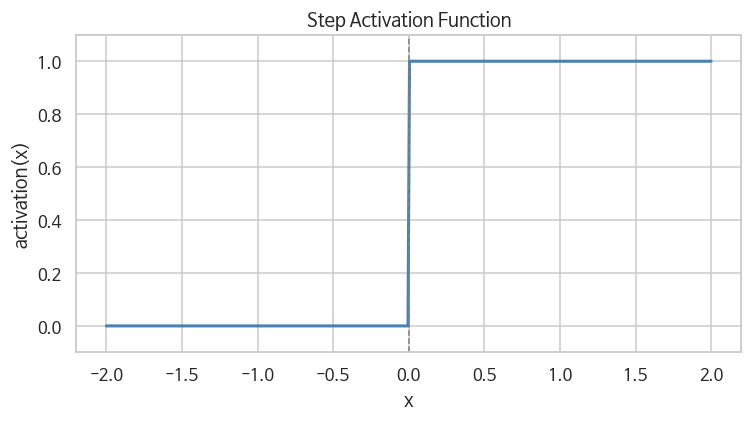

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

class StepActivation(nn.Module):
    """
    임계값(Threshold) 활성화 함수 (Step Function)
    - 입력값이 0 이상이면 1, 0 미만이면 0을 반환합니다.
    - 퍼셉트론의 최종 이진 분류(0 또는 1) 결정에 사용됩니다.
    """
    def __init__(self):
        super().__init__()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # 1. (x >= 0) 연산을 통해 조건 만족 여부를 가진 Boolean 텐서(True/False)를 생성합니다.
        # 2. .to(dtype=torch.float32)를 통해 True는 1.0, False는 0.0인 실수형 텐서로 변환합니다.
        return (x >= 0).to(dtype=torch.float32)


class SingleLayerPerceptron(nn.Module):
    """
    단층 퍼셉트론 (Single-Layer Perceptron)
    - 입력층(Input Layer)에서 데이터를 받아 은닉층 없이 바로 출력층(Output Layer)으로 연결됩니다.
    - 선형 변환(y = Wx + b) 후 Step 활성화 함수를 통과시켜 최종 출력을 얻습니다.
    """

    def __init__(self, in_features: int = 2):
        super().__init__()
        # nn.Linear(입력 차원, 출력 차원, bias=True)
        # - 가중치(Weight, W)의 크기: (1, in_features)
        # - 편향(Bias, b)의 크기: (1,) (bias=True이므로 자동으로 편향 b를 생성하고 학습 대상에 포함)
        self.linear = nn.Linear(in_features, 1, bias=True)

        # 앞서 정의한 StepActivation 인스턴스 생성
        self.activation = StepActivation()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # 1. 선형 결합 계산: z = Wx + b
        #    - 입력 x의 크기가 (batch_size, in_features)일 때, z의 크기는 (batch_size, 1)이 됩니다.
        z = self.linear(x)

        # 2. 활성화 함수 적용: y = Step(z)
        #    - 0을 기준으로 0보다 크거나 같으면 1.0, 작으면 0.0으로 이진화합니다.
        y = self.activation(z)

        return y


# =====================================================================
# 시각화 부분 (Visualization)
# =====================================================================

# 1. -2부터 2 사이의 구간을 균등하게 400개로 나눈 1차원 텐서 생성 (X축 데이터)
x_plot = torch.linspace(-2, 2, 400)

# 2. 생성한 X축 데이터를 Step Activation 함수에 통과시켜 Y축 데이터 계산
#    - StepActivation 인스턴스를 즉석에서 생성하여 함수처럼 호출(forward 실행)합니다.
y_plot = StepActivation()(x_plot)

# 3. Matplotlib을 이용한 그래프 그리기
fig, ax = plt.subplots(figsize=(7, 4))

# PyTorch 텐서를 넘파이(Numpy) 배열로 변환하여 플로팅 (가독성을 위한 파란색 계열 적용)
ax.plot(x_plot.numpy(), y_plot.numpy(), color='steelblue', lw=2)

# x=0 지점에 회색 점선으로 기준선(임계값 경계) 표시
ax.axvline(0, color='gray', ls='--', lw=1)

# 그래프 정보(제목, 축 레이블, 축 범위 제한) 설정
ax.set_title('Step Activation Function')
ax.set_xlabel('x')
ax.set_ylabel('activation(x)')
ax.set_ylim(-0.1, 1.1)  # y축의 위아래 마진을 살짝 주어 0과 1 선이 잘 보이도록 조정

# 여백을 자동 조절한 뒤 화면에 그래프 출력
plt.tight_layout()
plt.show()

---
# 03. 퍼셉트론 선형 분류기

## 단층 퍼셉트론

입력층과 출력층만으로 구성된 신경망입니다.  
0/1 논리 게이트를 **직선(선형 결정 경계)** 으로 분류할 수 있습니다.

## 논리 게이트 규칙 (강의 자료)

- **AND**: $C = activation(1\cdot A + 1\cdot B - 1.5)$
- **OR**: $C = activation(1\cdot A + 1\cdot B - 0.5)$
- **NAND**: $C = activation((-1)\cdot A + (-1)\cdot B + 1.5)$
- **NOR**: $C = activation((-1)\cdot A + (-1)\cdot B + 0.5)$

아래에서는 `torch.no_grad()` 모드에서 가중치와 편향을 **수동 지정**합니다.


In [ ]:
import torch
import pandas as pd

def make_gate(weights: list[float], bias: float) -> SingleLayerPerceptron:
    """
    강의 자료의 가중치(Weights)와 편향(Bias)을 수동으로 바인딩(수정)한 단층 퍼셉트론을 만듭니다.

    - weights: [w1, w2] 형태의 가중치 리스트
    - bias: 편향 값 b (실수)
    """
    # 2개의 입력을 받는 퍼셉트론 모델 생성
    model = SingleLayerPerceptron(in_features=2)

    # 텐서 복사 및 값 직접 수정 시에는 연산 그래프 추적을 방지하기 위해
    # torch.no_grad() 블록 안에서 안전하게 가중치를 주입합니다.
    with torch.no_grad():
        # model.linear.weight의 원래 크기인 (1, 2)에 맞게
        # [weights] 형태로 2차원 텐서를 만든 뒤 inplace copy (copy_)를 수행합니다.
        model.linear.weight.copy_(torch.tensor([weights], dtype=torch.float32))

        # model.linear.bias의 원래 크기인 (1,)에 맞게
        # [bias] 형태로 1차원 텐서를 만든 뒤 inplace copy (copy_)를 수행합니다.
        model.linear.bias.copy_(torch.tensor([bias], dtype=torch.float32))

    return model


# ---------------------------------------------------------------------
# 1. 강의 자료 기준 각 논리 게이트의 수학적 설계 (w1, w2, b)
# ---------------------------------------------------------------------
# AND Gate  : x1 + x2 - 1.5 >= 0 -> 둘 다 1일 때만 1 (1 + 1 - 1.5 = 0.5)
and_gate = make_gate([1.0, 1.0], -1.5)

# OR Gate   : x1 + x2 - 0.5 >= 0 -> 하나라도 1이면 1 (1 + 0 - 0.5 = 0.5)
or_gate = make_gate([1.0, 1.0], -0.5)

# NAND Gate : -x1 - x2 + 1.5 >= 0 -> AND의 반대 (둘 다 1일 때 -1 - 1 + 1.5 = -0.5 < 0 이므로 0)
nand_gate = make_gate([-1.0, -1.0], 1.5)

# NOR Gate  : -x1 - x2 + 0.5 >= 0 -> OR의 반대 (하나라도 1이면 -1 - 0 + 0.5 = -0.5 < 0 이므로 0)
nor_gate = make_gate([-1.0, -1.0], 0.5)


# ---------------------------------------------------------------------
# 2. 진리표 평가를 위한 입력 데이터 정의
# ---------------------------------------------------------------------
# (A, B) 쌍으로 구성된 4가지 경우의 수 (크기: 4x2 텐서)
inputs = torch.tensor([
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0],
], dtype=torch.float32)

# 순회 및 출력을 편리하게 하기 위해 딕셔너리로 게이트들을 매핑
gates = {
    'AND': and_gate,
    'OR': or_gate,
    'NAND': nand_gate,
    'NOR': nor_gate,
}


# ---------------------------------------------------------------------
# 3. 각 입력에 대해 4가지 게이트의 연산 결과 도출 및 진리표 작성
# ---------------------------------------------------------------------
print('=== 단층 퍼셉트론 논리 게이트 진리표 ===')
rows = []

# 평가 모드(가중치 업데이트 없음)이므로 no_grad 컨텍스트 안에서 실행
with torch.no_grad():
    for a, b in inputs:
        # 출력과 DataFrame 변환을 위해 소수점 데이터를 정수(int)로 변환하여 딕셔너리 생성
        row = {'A': int(a.item()), 'B': int(b.item())}

        # 모델의 입력 형식에 맞게 배치 차원을 추가하여 2차원 텐서 (1, 2) 형태로 변환
        x = torch.tensor([[a.item(), b.item()]], dtype=torch.float32)

        # 4개의 게이트를 순회하며 출력 계산
        for name, gate in gates.items():
            # gate(x)의 결과 텐서에서 실수 값을 꺼내 정수(0 또는 1)로 변환 후 저장
            row[name] = int(gate(x).item())

        rows.append(row)

        # 콘솔 창에 한 줄씩 직관적으로 결과 출력
        print(f"A={row['A']}, B={row['B']} | AND={row['AND']} OR={row['OR']} NAND={row['NAND']} NOR={row['NOR']}")

# 4. 수집한 행 데이터를 바탕으로 깔끔한 Pandas DataFrame 생성 및 확인
truth_df = pd.DataFrame(rows)
truth_df

=== 단층 퍼셉트론 논리 게이트 진리표 ===
A=0, B=0 | AND=0 OR=0 NAND=1 NOR=1
A=0, B=1 | AND=0 OR=1 NAND=1 NOR=0
A=1, B=0 | AND=0 OR=1 NAND=1 NOR=0
A=1, B=1 | AND=1 OR=1 NAND=0 NOR=0


,A,B,AND,OR,NAND,NOR
0,0,0,0,0,1,1
1,0,1,0,1,1,0
2,1,0,0,1,1,0
3,1,1,1,1,0,0


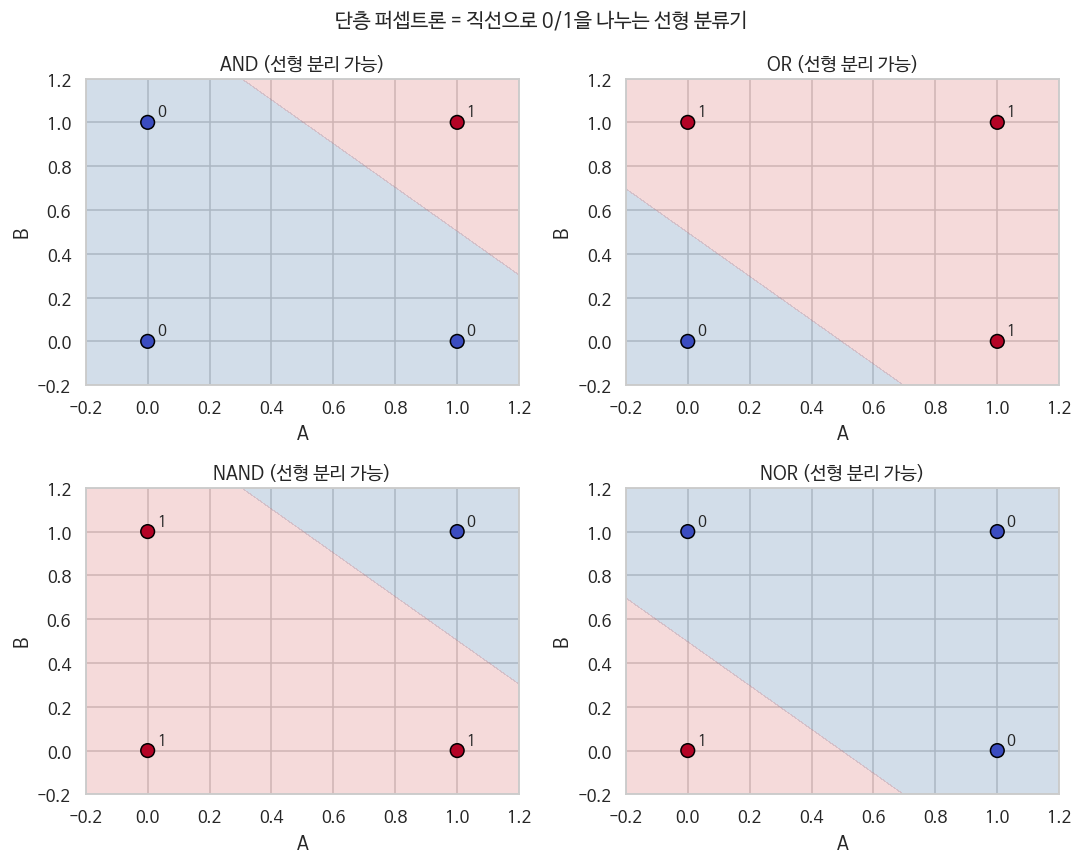

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def plot_decision_boundary(model, title, ax):
    """
    2D 입력 공간(A, B)에서 단층 퍼셉트론의 선형 결정 경계와 데이터 분포를 시각화합니다.

    - model: 평가할 퍼셉트론 모델 (예: and_gate, or_gate 등)
    - title: 서브플롯의 제목
    - ax: 그래프를 그릴 Matplotlib Axes 객체
    """
    # 1. 시각화할 2D 평면 공간의 격자점(Grid points)을 생성합니다.
    #    - 입력 변수 A와 B의 범위를 각각 -0.2부터 1.2까지 200등분합니다.
    #    - xx, yy는 각각 (200, 200) 크기의 2차원 배열이 됩니다.
    xx, yy = np.meshgrid(np.linspace(-0.2, 1.2, 200), np.linspace(-0.2, 1.2, 200))

    # 2. 2차원 격자점들을 하나의 평평한 2D 좌표 리스트 형태로 변환합니다.
    #    - xx.ravel()과 yy.ravel()로 (40000,) 형태의 1차원 배열을 만든 뒤,
    #    - np.c_[]를 사용해 두 열을 합쳐 (40000, 2) 크기의 행렬을 만듭니다.
    #    - 모델 입력에 사용할 수 있도록 PyTorch의 float32 타입 텐서로 변환합니다.
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

    # 3. 생성한 격자점 전체에 대해 모델의 예측 결과(0 또는 1)를 계산합니다.
    with torch.no_grad():
        # grid를 모델에 입력하여 결과를 얻은 뒤,
        # 등고선을 그릴 수 있도록 원래 격자 크기인 (200, 200)으로 되돌리고(reshape) 넘파이 배열로 변환합니다.
        zz = model(grid).reshape(xx.shape).numpy()

    # 4. 결정 경계면을 색상 영역(Contourf)으로 시각화합니다.
    #    - levels: 분류 경계값(0.5)을 기준으로 영역을 나눕니다. [-0.1 ~ 0.5]는 0 영역, [0.5 ~ 1.1]은 1 영역입니다.
    #    - colors: 각 영역의 배경 색상을 파란색('#4C78A8')과 빨간색('#D96C6C')으로 채웁니다.
    ax.contourf(xx, yy, zz, levels=[-0.1, 0.5, 1.1], alpha=0.25, colors=['#4C78A8', '#D96C6C'])

    # 5. 실제 진리표의 4가지 입력 데이터 포인트(pts)를 넘파이 배열로 변환합니다.
    pts = inputs.numpy()

    # 6. 진리표 입력에 대한 모델의 예측값(라벨)을 구합니다.
    with torch.no_grad():
        # model(inputs)의 결과 크기 (4, 1)을 1차원 (4,)로 찌그러뜨린(squeeze) 뒤 넘파이 배열로 바꿉니다.
        labels = model(inputs).squeeze().numpy()

    # 7. 4개의 데이터 포인트를 산점도(Scatter plot)로 표현합니다.
    #    - c=labels, cmap='coolwarm': 예측 결과가 0이면 파란색 계열, 1이면 빨간색 계열로 점의 색상을 지정합니다.
    #    - s=80: 점의 크기, edgecolor='black': 점의 테두리를 검은색으로 그립니다.
    ax.scatter(pts[:, 0], pts[:, 1], c=labels, cmap='coolwarm', s=80, edgecolor='black')

    # 8. 각 데이터 포인트 근처에 실제 예측값(0 또는 1)을 텍스트로 표시합니다.
    for (a, b), yhat in zip(pts, labels):
        # 겹치지 않도록 아주 약간 우상단(+0.03) 위치에 텍스트를 출력합니다.
        ax.text(a + 0.03, b + 0.03, f'{int(yhat)}', fontsize=10)

    # 9. 그래프 축 설정 및 스타일링
    ax.set_xlim(-0.2, 1.2)   # X축 범위 제한
    ax.set_ylim(-0.2, 1.2)   # Y축 범위 제한
    ax.set_xlabel('A')       # X축 레이블
    ax.set_ylabel('B')       # Y축 레이블
    ax.set_title(title)      # 각 서브플롯의 제목


# ---------------------------------------------------------------------
# 4개의 논리 게이트 시각화 그리드 그리기 (2행 2열)
# ---------------------------------------------------------------------
# 2행 2열 구조의 캔버스(figsize: 가로 10, 세로 8)를 구성합니다.
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# 각 논리 게이트를 해당하는 서브플롯 위치(axes)에 그립니다.
plot_decision_boundary(and_gate, 'AND (선형 분리 가능)', axes[0, 0])   # 1행 1열
plot_decision_boundary(or_gate, 'OR (선형 분리 가능)', axes[0, 1])     # 1행 2열
plot_decision_boundary(nand_gate, 'NAND (선형 분리 가능)', axes[1, 0]) # 2행 1열
plot_decision_boundary(nor_gate, 'NOR (선형 분리 가능)', axes[1, 1])   # 2행 2열

# 전체 그래프를 아우르는 통합 타이틀 설정
fig.suptitle('단층 퍼셉트론 = 직선으로 0/1을 나누는 선형 분류기', fontsize=13)

# 플롯 간 여백 정렬 후 최종 화면 출력
plt.tight_layout()
plt.show()

---
# 04. 비선형적인 문제 (XOR)

## 단층 퍼셉트론의 한계

XOR은 입력이 서로 다를 때만 1을 출력합니다.

| A | B | XOR |
|---|---|-----|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

한 직선으로는 `(0,1)`과 `(1,0)`을 같은 쪽, `(0,0)`과 `(1,1)`을 다른 쪽으로 동시에 나눌 수 없습니다.  
이 한계가 증명되며 **1969년 첫 번째 AI 겨울**로 이어졌습니다.

## 관련 논문

- Minsky & Papert (1969): [Perceptrons](https://mitpress.mit.edu/9780262631112/perceptrons/)
- 요약 자료: [XOR problem and multilayer networks](https://en.wikipedia.org/wiki/Perceptron#Limitations)


=== 단층 퍼셉트론으로 XOR 학습 시도 ===
예측 확률: [0.5 0.5 0.5 0.5]
예측 라벨: [1 1 1 1]
정답     : [0 1 1 0]
정확도   : 0.5


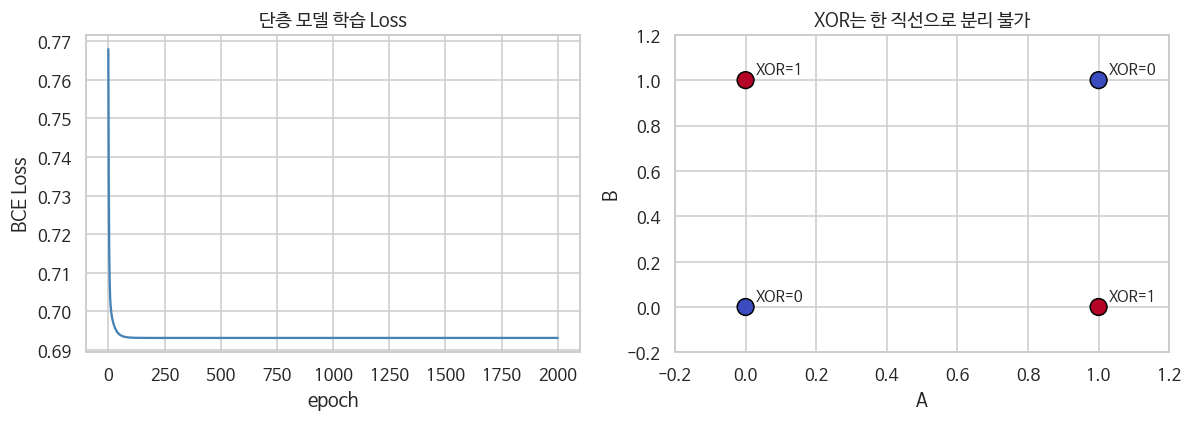

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 1. XOR 진리표의 정답(Target) 정의
#    - 입력이 서로 다를 때만 1, 같으면 0을 반환해야 합니다.
#    - (0,0)->0, (0,1)->1, (1,0)->1, (1,1)->0
xor_targets = torch.tensor([[0.0], [1.0], [1.0], [0.0]], dtype=torch.float32)

# 2. 단층 퍼셉트론 구조의 한계를 실험하기 위한 임시 모델 생성
#    - 기존 Step 함수는 도함수(미분값)가 거의 모든 곳에서 0이므로 경사하강법(Backpropagation)을 통한 학습이 불가능합니다.
#    - 따라서 학습 진행을 위해 출력 범위가 (0, 1)이면서 미분 가능한 Sigmoid 활성화 함수를 결합한 Sequential 모델을 사용합니다.
single_learnable = nn.Sequential(
    nn.Linear(2, 1),   # 2차원 입력을 1차원으로 선형 변환 (W1*x1 + W2*x2 + b)
    nn.Sigmoid(),      # 선형 변환 결과를 0과 1 사이의 확률값으로 스쿼싱(Squashing)
)

# 3. 이진 분류(Binary Classification)를 위한 손실 함수 및 옵티마이저 설정
#    - BCELoss (Binary Cross Entropy Loss): 예측 확률과 실제 0/1 정답 간의 오차를 계산합니다.
#    - SGD (Stochastic Gradient Descent): 가중치 파라미터를 업데이트할 경사하강법 옵티마이저 (학습률 lr = 0.5)
criterion = nn.BCELoss()
optimizer = optim.SGD(single_learnable.parameters(), lr=0.5)

# 4. 학습 루프 진행 (2,000 에포크)
loss_history = []
for epoch in range(2000):
    # 1) 이전 스텝에서 계산된 그라디언트(기울기)를 초기화합니다.
    optimizer.zero_grad()

    # 2) 순전파(Forward pass): 현재 가중치로 입력을 통과시켜 예측값 계산 (크기: 4x1 텐서)
    pred = single_learnable(inputs)

    # 3) 손실값(Loss) 계산: 예측값과 실제 XOR 정답 간의 오차 측정
    loss = criterion(pred, xor_targets)

    # 4) 역전파(Backward pass): 오차를 바탕으로 각 가중치의 그라디언트 계산
    loss.backward()

    # 5) 가중치 업데이트: 계산된 그라디언트 방향으로 파라미터 미세 조정
    optimizer.step()

    # 시각화를 위해 매 에포크의 손실값을 기록
    loss_history.append(loss.item())

# 5. 학습 완료 후 최종 평가 진행 (Gradient 추적 비활성화)
with torch.no_grad():
    # 학습된 모델의 최종 예측 확률 계산 (0.0 ~ 1.0 사이 값)
    pred_prob = single_learnable(inputs)

    # 임계값 0.5를 기준으로 0.5 이상이면 1.0, 미만이면 0.0으로 최종 라벨 결정
    pred_label = (pred_prob >= 0.5).float()

# 6. 예측 결과 콘솔 출력
#    - XOR는 단일 직선으로 영역을 나눌 수 없으므로, 예측 라벨이 전부 0이나 1로 쏠리거나 정확도가 약 50% 수준에 머무는 것을 확인할 수 있습니다.
print('=== 단층 퍼셉트론으로 XOR 학습 시도 ===')
print('예측 확률:', pred_prob.squeeze().numpy().round(3)) # 차원을 줄여 1차원 배열 형태로 가볍게 출력
print('예측 라벨:', pred_label.squeeze().numpy().astype(int))
print('정답     :', xor_targets.squeeze().numpy().astype(int))
# 예측값과 실제 정답이 일치하는 비율을 계산하여 평균을 냄 (정확도 계산)
print('정확도   :', float((pred_label == xor_targets).float().mean()))


# ---------------------------------------------------------------------
# 7. 학습 곡선 및 XOR 데이터 분포 시각화
# ---------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# [왼쪽 그래프]: 에포크에 따른 손실값 추이 (BCE Loss)
# - 학습이 진행되어도 선형 분류기의 특성상 오차가 일정 수준 이하로 떨어지지 않고 정체됩니다.
axes[0].plot(loss_history, color='steelblue')
axes[0].set_title('단층 모델 학습 Loss')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('BCE Loss')

# [오른쪽 그래프]: XOR 입력 평면상의 점 배치 시각화
pts = inputs.numpy()
# c=xor_targets를 통해 정답이 0인 점과 1인 점의 색상을 다르게 표현합니다.
axes[1].scatter(pts[:, 0], pts[:, 1], c=xor_targets.squeeze().numpy(), cmap='coolwarm', s=120, edgecolor='black')

# 각 점 위에 정답 레이블(XOR=0 또는 XOR=1) 텍스트 표시
for (a, b), t in zip(pts, xor_targets.squeeze().numpy()):
    axes[1].text(a + 0.03, b + 0.03, f'XOR={int(t)}', fontsize=10)

axes[1].set_title('XOR는 한 직선으로 분리 불가')
axes[1].set_xlim(-0.2, 1.2)
axes[1].set_ylim(-0.2, 1.2)
axes[1].set_xlabel('A')
axes[1].set_ylabel('B')

# 여백 조정 후 화면 출력
plt.tight_layout()
plt.show()

---
# 05. 다층 퍼셉트론 (MLP)

## 은닉층의 도입

단층으로는 안 되면, **퍼셉트론을 여러 층으로 쌓아** 비선형 문제를 풉니다.

$$
\text{입력층} \rightarrow \text{은닉층(Hidden Layer)} \rightarrow \text{출력층}
$$

- **은닉층**: 입력과 출력 사이의 중간 표현을 학습/조합하는 층
- **딥러닝**: 은닉층이 깊게(보통 여러 층) 쌓인 신경망

## XOR를 MLP로 푸는 고전적 조합

1. Hidden: $H_1 = NAND(A,B)$, $H_2 = OR(A,B)$
2. Output: $Y = AND(H_1, H_2)$

## 관련 논문

- Rumelhart, Hinton, Williams (1986): [Learning representations by back-propagating errors](https://www.nature.com/articles/323533a0)
- Cybenko (1989): [Approximation by Superpositions of a Sigmoidal Function](https://link.springer.com/article/10.1007/BF02551274) (보편 근사 정리)


## 방식 A. 수동 조합 MLP (NAND + OR → AND)

앞서 만든 게이트를 서브모듈처럼 연결합니다. 학습은 하지 않고, 강의 자료의 구조 그대로 XOR를 구현합니다.


In [ ]:
import torch
import torch.nn as nn

class ManualXOR(nn.Module):
    """
    방식 A: 수동 조합 다층 퍼셉트론 (MLP - Multi-Layer Perceptron)

    [구조 및 원리]
    - 입력층(Input Layer): 2차원 데이터 (A, B)를 입력받음
    - 은닉층(Hidden Layer): 하나의 입력을 NAND 게이트와 OR 게이트에 각각 통과시켜 비선형 특징 분리
      * H1 = NAND(A, B) -> 두 입력이 모두 1일 때만 0, 나머지는 1
      * H2 = OR(A, B)   -> 두 입력 중 하나라도 1이면 1, 둘 다 0이면 0
    - 출력층(Output Layer): 은닉층의 두 결과(H1, H2)를 다시 AND 게이트로 결합하여 최종 XOR 출력 도출
      * Y  = AND(H1, H2)
    """

    def __init__(self):
        super().__init__()
        # 앞서 구현한 make_gate 함수를 활용하여 고정된 가중치와 편향을 가진 게이트들을 생성합니다.
        self.nand = make_gate([-1.0, -1.0], 1.5)   # 은닉 노드 1 (NAND)
        self.or_gate = make_gate([1.0, 1.0], -0.5) # 은닉 노드 2 (OR)
        self.and_gate = make_gate([1.0, 1.0], -1.5) # 출력 노드 (AND)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # 1. 은닉층 연산 진행
        #    - 입력 x의 크기가 (batch_size, 2)일 때, h1과 h2의 크기는 각각 (batch_size, 1)이 됩니다.
        h1 = self.nand(x)          # 은닉층 유닛 1 (NAND 결과)
        h2 = self.or_gate(x)       # 은닉층 유닛 2 (OR 결과)

        # 2. 특징 병합 (Feature Concatenation)
        #    - dim=1(열 방향)로 두 텐서를 가로로 이어 붙입니다.
        #    - 크기 변화: (batch_size, 1) + (batch_size, 1) -> (batch_size, 2)
        hidden = torch.cat([h1, h2], dim=1)

        # 3. 출력층 연산 진행
        #    - 병합된 은닉층의 결과(2차원)를 AND 게이트에 통과시켜 최종 1차원 출력을 얻습니다.
        y = self.and_gate(hidden)

        return y


# =====================================================================
# 수동 조합 MLP XOR 게이트 검증 및 진리표 출력
# =====================================================================

# 1. 수동 조합 XOR 모델 인스턴스 생성
manual_xor = ManualXOR()

print('=== 방식 A: 수동 조합 MLP XOR 진리표 ===')
print('A B | H1=NAND H2=OR | XOR')
print('-' * 32)

# 가중치 업데이트가 없는 평가 과정이므로 grad 추적을 비활성화합니다.
with torch.no_grad():
    for a, b in inputs:
        # 모델 입력 포맷에 맞춰 (1, 2) 크기의 2차원 텐서로 변환
        x = torch.tensor([[a.item(), b.item()]], dtype=torch.float32)

        # 내부 동작 과정을 모니터링하기 위해 은닉층의 개별 출력값(H1, H2)을 추출합니다.
        h1 = manual_xor.nand(x).item()
        h2 = manual_xor.or_gate(x).item()

        # 전체 모델을 통과한 최종 예측 결과(Y)를 추출합니다.
        y = manual_xor(x).item()

        # 진리표 결과를 정수형으로 보기 좋게 정렬하여 출력
        print(f'{int(a)} {int(b)} |   {int(h1)}       {int(h2)}   |  {int(y)}')

# 2. 전체 입력 데이터에 대한 최종 정확도(Accuracy) 측정
with torch.no_grad():
    # 4개 입력 조합(4x2)을 한 번에 모델에 넣어 일괄 예측 수행 (출력 크기: 4x1)
    manual_pred = manual_xor(inputs)

# 예측된 라벨과 실제 XOR 정답(xor_targets)을 비교하여 평균 정답률을 계산합니다.
# - (manual_pred == xor_targets): 일치 여부를 담은 Boolean 텐서 생성
# - .float().mean(): True/False를 1.0/0.0으로 변환 후 평균 계산 (정확도 도출)
manual_acc = float((manual_pred == xor_targets).float().mean())

# 정확도 출력 (.0% 포맷으로 소수점 없이 백분율 표시 -> 100% 달성 확인 가능)
print(f'\n수동 조합 XOR 정확도: {manual_acc:.0%}')

=== 방식 A: 수동 조합 MLP XOR 진리표 ===
A B | H1=NAND H2=OR | XOR
--------------------------------
0 0 |   1       0   |  0
0 1 |   1       1   |  1
1 0 |   1       1   |  1
1 1 |   0       1   |  0

수동 조합 XOR 정확도: 100%


## 방식 B. PyTorch Autograd로 MLP 학습

이번에는 가중치를 사람이 넣지 않습니다.  
`nn.Linear(2, 2)` 은닉층 + `nn.Linear(2, 1)` 출력층을 두고, Sigmoid와 BCE Loss로 XOR를 학습합니다.

### 학습에 쓰는 핵심 수식

Sigmoid:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

Binary Cross Entropy:

$$
\mathcal{L} = -[y\log\hat{y} + (1-y)\log(1-\hat{y})]
$$


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class LearnableXOR(nn.Module):
    """
    방식 B: 학습 가능한 다층 퍼셉트론 (MLP - Multi-Layer Perceptron)

    [구조]
    - 입력층 (Input Layer): 2차원 데이터 (A, B)를 입력받음
    - 은닉층 (Hidden Layer):
      * nn.Linear(2, 2)를 통해 2차원 입력을 다른 2차원 특징 공간으로 선형 사영합니다.
      * nn.Sigmoid() 활성화 함수를 결합하여 비선형성(Non-linearity)을 부여합니다.
    - 출력층 (Output Layer):
      * nn.Linear(2, 1)을 통해 은닉층의 2차원 출력 정보를 1차원 실수값으로 축소합니다.
      * nn.Sigmoid()를 거쳐 최종 클래스 분류 확률 (0.0 ~ 1.0)을 출력합니다.
    """

    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(2, 2)   # 가중치 W_hidden: (2, 2), 편향 b_hidden: (2,)
        self.output = nn.Linear(2, 1)   # 가중치 W_output: (1, 2), 편향 b_output: (1,)
        self.activation = nn.Sigmoid()  # 모든 레이어의 활성화를 위한 미분 가능한 Sigmoid 함수

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # 1. 은닉층 연산: H = Sigmoid(X * W_hidden + b_hidden)
        #    - 크기 변화: (batch_size, 2) -> (batch_size, 2)
        h = self.activation(self.hidden(x))

        # 2. 출력층 연산: Y = Sigmoid(H * W_output + b_output)
        #    - 크기 변화: (batch_size, 2) -> (batch_size, 1)
        y = self.activation(self.output(h))

        return y


# =====================================================================
# 신경망 학습 객체 정의 및 파라미터 설정
# =====================================================================

# 1. 학습할 MLP 모델 인스턴스 초기화
mlp = LearnableXOR()

# 2. 손실 함수 (Loss Function): 이진 분류를 위한 Binary Cross Entropy Loss 사용
criterion = nn.BCELoss()

# 3. 옵티마이저 (Optimizer): 가속 경사법 및 모멘텀이 통합되어 수렴이 빠른 Adam 알고리즘 사용
#    - lr (Learning Rate, 학습률) = 0.1로 비교적 크게 설정하여 빠르게 수렴을 유도합니다.
#    - mlp.parameters()를 통해 학습 대상 가중치와 편향들을 최적화 대상으로 등록합니다.
optimizer = optim.Adam(mlp.parameters(), lr=0.1)

# 학습 경과(Loss 및 Accuracy)를 기록하기 위한 빈 리스트 정의
loss_hist = []
acc_hist = []


# =====================================================================
# 모델 학습 루프 (3,000 Epoch)
# =====================================================================
for epoch in range(3000):
    # 1) 그라디언트 초기화: 새로운 역전파 계산을 위해 이전 스텝의 기울기 누적값을 0으로 리셋합니다.
    optimizer.zero_grad()

    # 2) 순전파 (Forward Pass): 입력 데이터를 모델에 흘려보내 예측값(확률)을 구합니다.
    pred = mlp(inputs)

    # 3) 오차 계산 (Loss Computation): 예측 확률 분포와 실제 정답(0 또는 1) 사이의 엔트로피 오차 계산
    loss = criterion(pred, xor_targets)

    # 4) 역전파 (Backpropagation): 계산된 손실값(Loss)으로부터 입력 노드 방향으로 편미분(Gradient)을 역방향 전파합니다.
    loss.backward()

    # 5) 가중치 업데이트 (Step): 계산된 그라디언트를 사용하여 모델의 가중치와 편향을 한 단계 업데이트합니다.
    optimizer.step()

    # 가중치가 변하지 않는 평가 구간에서 미분 그래프 빌드를 막아 메모리를 보존합니다.
    with torch.no_grad():
        # 예측값(확률)이 0.5 이상이면 1.0, 미만이면 0.0으로 이진 분류 라벨을 생성합니다.
        pred_label = (pred >= 0.5).float()

        # 실제 XOR 정답과 일치하는 개수의 평균을 구해 현재 에포크의 정확도를 계산합니다.
        acc = (pred_label == xor_targets).float().mean().item()

    # 학습 히스토리에 현재 에포크 정보 누적
    loss_hist.append(loss.item())
    acc_hist.append(acc)

    # 500 에포크마다 학습 진행 상황(손실률, 정확도)을 모니터링하기 위해 출력합니다.
    if (epoch + 1) % 500 == 0:
        print(f'Epoch {epoch+1:4d} | Loss={loss.item():.4f} | Acc={acc:.0%}')


# =====================================================================
# 학습 완료 후 최종 검증 및 파라미터 확인
# =====================================================================

# 가중치 업데이트 없이 순수 순전파 계산만 수행
with torch.no_grad():
    # 학습이 끝난 모델의 최종 예측 확률 계산 (크기: 4x1)
    final_prob = mlp(inputs)

    # 임계값 0.5를 기준으로 이진 라벨링
    final_pred = (final_prob >= 0.5).float()

print('\n=== 방식 B: 학습된 MLP XOR 진리표 ===')
print('A B | 확률   | 예측 | 정답')
print('-' * 28)

# 4개의 XOR 입력 샘플에 대해 순회하며 한 줄씩 평가 결과를 정렬하여 출력합니다.
for i, (a, b) in enumerate(inputs):
    print(
        f'{int(a)} {int(b)} | {final_prob[i].item():.3f} | '
        f'{int(final_pred[i].item())}    | {int(xor_targets[i].item())}'
    )

# 모델의 최종 예측 정확도를 계산합니다.
learned_acc = float((final_pred == xor_targets).float().mean())
print(f'\n학습 MLP XOR 정확도: {learned_acc:.0%}')

# 경사하강법을 통해 데이터로부터 직접 학습하고 도출해낸 은닉층과 출력층의 가중치(Weight)와 편향(Bias) 값들을 확인합니다.
print('\n학습된 은닉층 weight:\n', mlp.hidden.weight.data)
print('학습된 은닉층 bias:\n', mlp.hidden.bias.data)
print('학습된 출력층 weight:\n', mlp.output.weight.data)
print('학습된 출력층 bias:\n', mlp.output.bias.data)

Epoch  500 | Loss=0.0023 | Acc=100%
Epoch 1000 | Loss=0.0008 | Acc=100%
Epoch 1500 | Loss=0.0004 | Acc=100%
Epoch 2000 | Loss=0.0002 | Acc=100%
Epoch 2500 | Loss=0.0001 | Acc=100%
Epoch 3000 | Loss=0.0001 | Acc=100%

=== 방식 B: 학습된 MLP XOR 진리표 ===
A B | 확률   | 예측 | 정답
----------------------------
0 0 | 0.000 | 0    | 0
0 1 | 1.000 | 1    | 1
1 0 | 1.000 | 1    | 1
1 1 | 0.000 | 0    | 0

학습 MLP XOR 정확도: 100%

학습된 은닉층 weight:
 tensor([[ -8.9225,  -8.9378],
        [-10.7788, -10.8854]])
학습된 은닉층 bias:
 tensor([13.2675,  5.0201])
학습된 출력층 weight:
 tensor([[ 18.7878, -19.0328]])
학습된 출력층 bias:
 tensor([-9.1680])


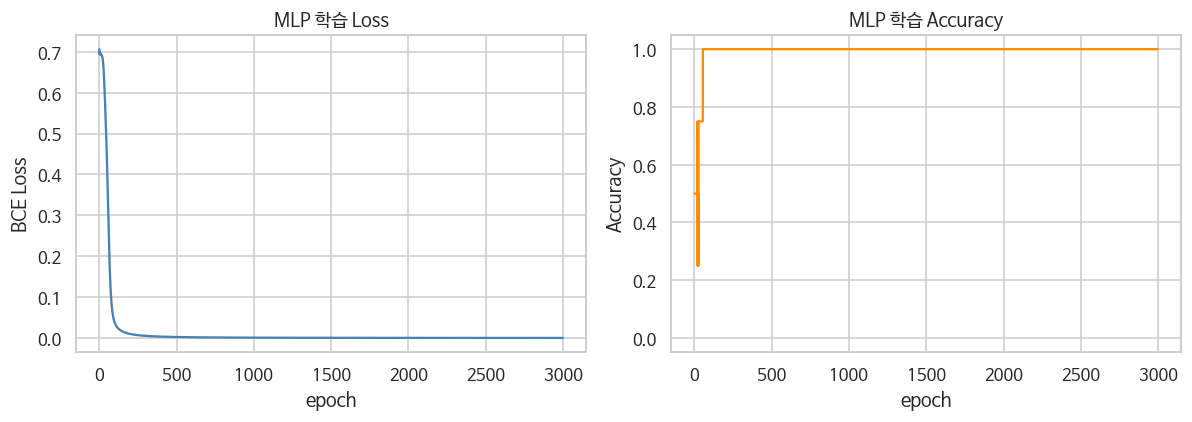

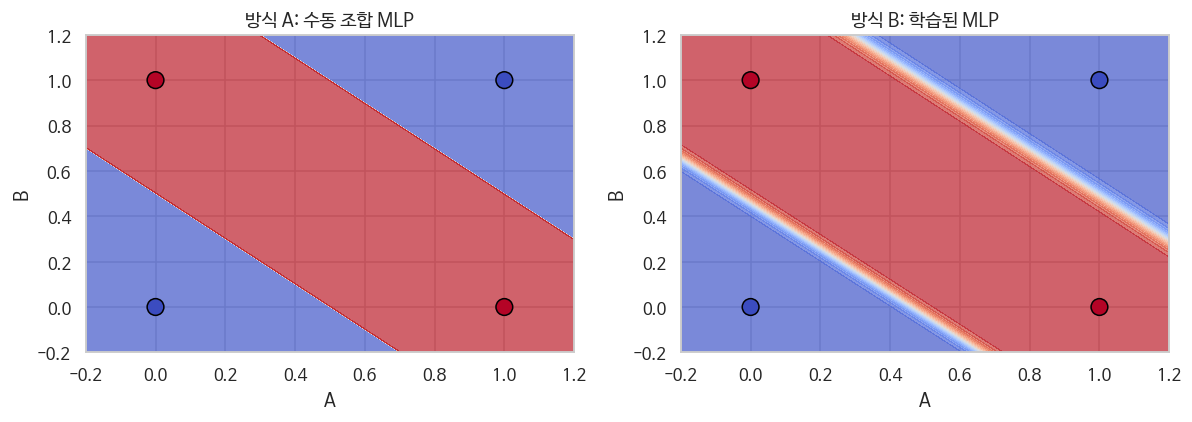

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# =====================================================================
# 1. 학습 과정 추이 시각화 (Loss & Accuracy)
# =====================================================================
# 가로로 나란히 배치할 2개의 서브플롯(1행 2열) 생성 (크기: 11 x 4)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# [왼쪽 그래프]: 에포크에 따른 오차(Loss) 감소 추이
# - 학습이 안정적으로 진행되면서 이진 크로스 엔트로피 손실(BCE Loss)이 0에 가깝게 하강하는지 확인합니다.
axes[0].plot(loss_hist, color='steelblue')
axes[0].set_title('MLP 학습 Loss')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('BCE Loss')

# [오른쪽 그래프]: 에포크에 따른 정확도(Accuracy) 상승 추이
# - 초기에는 50% 수준(선형 분류의 한계)에 머물다가, 은닉층이 특징을 잡아내는 순간 100%(1.0)로 도약하는 구간을 볼 수 있습니다.
axes[1].plot(acc_hist, color='darkorange')
axes[1].set_title('MLP 학습 Accuracy')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(-0.05, 1.05)  # 정확도의 범위가 0%에서 100%임을 명확히 보여주기 위해 y축 가이드라인을 고정

# 서브플롯 간 여백 자동 맞춤 및 화면 출력
plt.tight_layout()
plt.show()


# =====================================================================
# 2. 다층 퍼셉트론(MLP)의 비선형 결정 경계 시각화 함수
# =====================================================================
def plot_mlp_boundary(model, title, ax):
    """
    2D 평면 위에 다층 퍼셉트론의 유연한 비선형 결정 경계를 시각화합니다.
    단층 퍼셉트론의 칼로 자른듯한 직선과 달리, 꺾이거나 부드러운 곡선 형태의 경계를 볼 수 있습니다.
    """
    # 1. 평면을 촘촘하게 메울 2차원 격자점 생성 (-0.2부터 1.2 사이를 300등분)
    xx, yy = np.meshgrid(np.linspace(-0.2, 1.2, 300), np.linspace(-0.2, 1.2, 300))

    # 2. 격자점들을 가로로 나열하여 (90000, 2) 크기의 PyTorch 실수형 텐서로 변환
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

    # 3. 모델을 통과시켜 평면 위의 모든 점에 대한 예측 확률값을 구합니다.
    with torch.no_grad():
        # (90000, 1)의 출력을 원래 격자 모양인 (300, 300)으로 되돌리고 numpy 배열로 변환
        zz = model(grid).reshape(xx.shape).numpy()

    # 4. 등고선 플롯(contourf)으로 결정 경계를 그립니다.
    #    - levels=20: 확률값(0.0 ~ 1.0)을 20단계로 촘촘히 쪼개어, 경계면이 변하는 단계를 부드러운 그라데이션으로 표현합니다.
    #    - cmap='coolwarm': 0에 가까우면 파란색, 1에 가까우면 빨간색, 경계면(0.5 근처)은 흰색/회색 계열로 칠합니다.
    ax.contourf(xx, yy, zz, levels=20, cmap='coolwarm', alpha=0.7)

    # 5. 실제 데이터 포인트들을 그 위에 흩뿌립니다(Scatter).
    pts = inputs.numpy()
    # xor_targets를 기준으로 정답 색상을 매핑 (True=빨간색, False=파란색)
    ax.scatter(pts[:, 0], pts[:, 1], c=xor_targets.squeeze().numpy(), cmap='coolwarm', s=120, edgecolor='black')

    # 6. 각 서브플롯의 속성(제목, 축 이름) 정의
    ax.set_title(title)
    ax.set_xlabel('A')
    ax.set_ylabel('B')


# =====================================================================
# 3. 수동 설계 MLP vs 학습된 MLP 결정 경계 비교 시각화
# =====================================================================
# 가로로 나란히 비교할 수 있는 1행 2열 구조의 캔버스 생성
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# [왼쪽]: 규칙을 수동으로 조합하여 설계한 MLP (NAND + OR -> AND)
# - 수동 조합은 활성화 함수로 Step Function을 연쇄적으로 썼기 때문에,
#   중간 경계선 영역이 그라데이션 없이 딱딱하게 꺾인 직선들의 조합 형태로 나타납니다.
plot_mlp_boundary(manual_xor, '방식 A: 수동 조합 MLP', axes[0])

# [오른쪽]: 역전파와 경사하강법을 통해 알아서 학습한 MLP
# - 활성화 함수로 미분 가능한 부드러운 Sigmoid를 연속해서 사용했기 때문에,
#   두 정답 영역(0과 1)을 가르는 경계면이 매우 부드러운 곡선(그라데이션)의 형태로 자연스럽게 이어져 있습니다.
plot_mlp_boundary(mlp, '방식 B: 학습된 MLP', axes[1])

# 플롯 간 레이아웃 정돈 및 화면 출력
plt.tight_layout()
plt.show()

- 이 그림은 앞서 우리가 다룬 **XOR 비선형 문제를 해결하는 두 가지 다층 퍼셉트론(MLP) 방식**의 '결정 경계(Decision Boundary)' 차이를 시각적으로 보여주는 그래프입니다.
- XOR 연산은 입력 데이터 $A$와 $B$가 서로 다를 때만 1(빨간 점)을 출력하고, 같을 때는 0(파란 점)을 출력해야 합니다. 그림을 보면 두 방식 모두 빨간 점과 파란 점을 정확하게 분리해 내고 있습니다.

---

### 1. 왼쪽 그림: 방식 A (수동 조합 MLP)

* **특징**: 사람이 강의 자료에 나오는 가중치와 편향 수식을 기반으로 **NAND, OR, AND 게이트를 수학적으로 결합**하여 만든 모델입니다.


* **경계선 형태 (선형의 조합)**:
* 그림을 보면 **두 개의 날카로운 직선**이 평면을 대각선으로 가로지르고 있습니다.
* 하나의 단층 퍼셉트론(직선 하나)으로는 절대 분리할 수 없었던 공간을, 은닉층을 두어 **직선 두 개를 조합**함으로써 가운데 빨간 영역(1)과 양 끝의 파란 영역(0)으로 무 자르듯 칼 같이 분리한 모습입니다.





### 2. 오른쪽 그림: 방식 B (학습된 MLP)

* **특징**: 가중치를 사람이 정해주지 않고, 파이토치(PyTorch)나 텐서플로우(TensorFlow) 같은 프레임워크를 통해 **오차역전파(Backpropagation)와 가중치 최적화로 컴퓨터가 스스로 학습**하여 찾은 모델입니다.


* **경계선 형태 (부드러운 곡선과 그라데이션)**:
* 은닉층에서 시그모이드(Sigmoid)나 ReLU 같은 부드러운 활성화 함수를 거치며 학습되었기 때문에, 결정 경계가 딱딱한 직선이 아니라 **부드러운 곡선 형태**를 띠고 있습니다.


* 색상이 흐려지는 그라데이션 영역은 모델이 결과를 출력할 때 0 또는 1이라고 확신하는 정도(확률)가 연속적으로 변하는 구간을 의미합니다.





---

### 요약하자면

* **방식 A**는 사람이 규칙(논리 게이트)을 조합하여 기하학적(직선적)으로 공간을 분리한 결과이고,


* **방식 B**는 인공지능이 데이터를 보고 스스로 최적의 패턴을 찾아 **확률적이고 부드러운 곡선**으로 공간을 분리한 결과입니다.



결국 **두 방식 모두 단층 퍼셉트론의 한계(비선형 문제)를 은닉층을 쌓음으로써 완벽하게 극복했음**을 시각적으로 증명하는 아주 좋은 자료입니다.

---
# 정리

1. **단층 퍼셉트론**은 $y = step(Wx + b)$ 형태의 선형 분류기입니다.
2. AND/OR/NAND/NOR는 적절한 가중치로 단층에서 구현 가능합니다.
3. **XOR는 단층으로 풀 수 없습니다.** (1969, Minsky & Papert)
4. **MLP**는 은닉층을 통해 비선형 경계를 만듭니다.
5. 방식 A는 사람이 게이트를 조합하고, 방식 B는 PyTorch Autograd가 가중치를 스스로 찾습니다.

## 핵심 논문 다시 보기

- Rosenblatt (1958): [Perceptron](https://psycnet.apa.org/doi/10.1037/h0042519)
- Minsky & Papert (1969): [Perceptrons](https://mitpress.mit.edu/9780262631112/perceptrons/)
- Rumelhart, Hinton, Williams (1986): [Backpropagation](https://www.nature.com/articles/323533a0)
- Cybenko (1989): [Universal Approximation](https://link.springer.com/article/10.1007/BF02551274)
